In [8]:
import json

import matplotlib.pyplot as plt
from persiantools.digits import en_to_fa
import arabic_reshaper
from bidi.algorithm import get_display
import numpy as np

In [20]:
ALGORITHMS = [
    "DYNAMOSA",
    "MOSA",
    "MIO",
    "RANDOM",
    "RANDOM_TEST_CASE_SEARCH",
    "RANDOM_TEST_SUITE_SEARCH",
    "WHOLE_SUITE",
]

info = {}
for algo in ALGORITHMS:
    info[algo] = {"time": {"t": [], "cov": []},
                  "no_time": {"t": [], "cov": []},
                  "mem": {"t": [], "cov": []},
                  "no_mem": {"t": [], "cov": []}
                 }
    for suffix in ["time", "no_time", "mem", "no_mem"]:
        with open(f"../results/refined/{algo}_{suffix}", 'r', encoding='utf-8') as f:
            first_t = None
            for line in f:
                d = json.loads(line)
                first_t = d["time"] if first_t is None else first_t
                info[algo][suffix]["t"].append(d["time"]-first_t)
                info[algo][suffix]["cov"].append(d["coverage"]*100)
    print(f"Processed {algo}")

Processed DYNAMOSA
Processed MOSA
Processed MIO
Processed RANDOM
Processed RANDOM_TEST_CASE_SEARCH
Processed RANDOM_TEST_SUITE_SEARCH
Processed WHOLE_SUITE


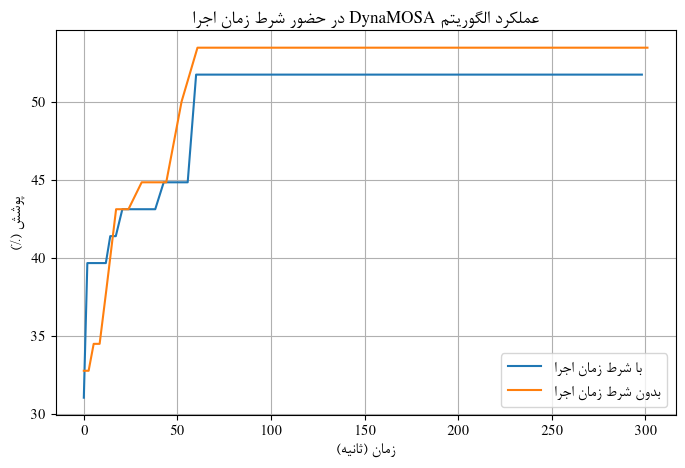

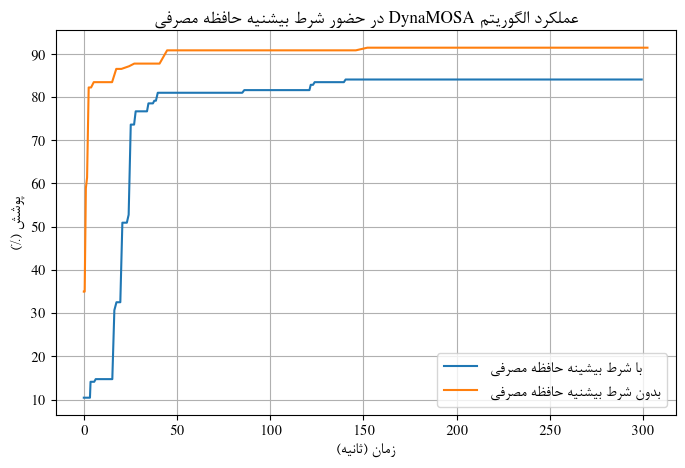

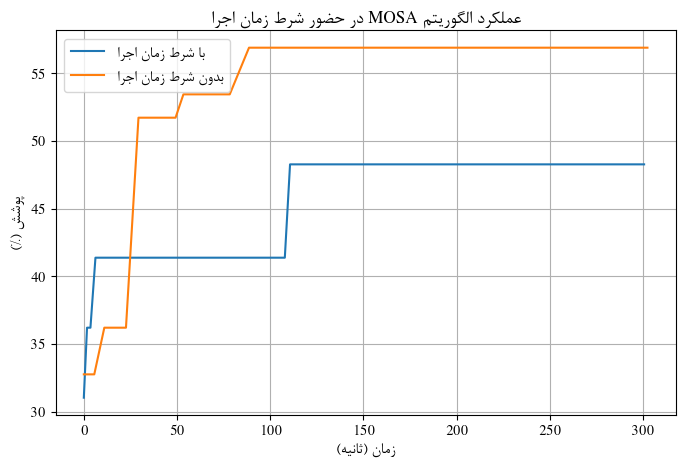

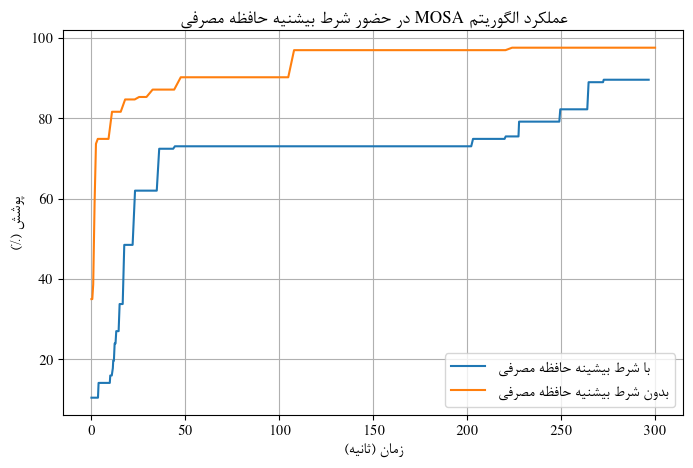

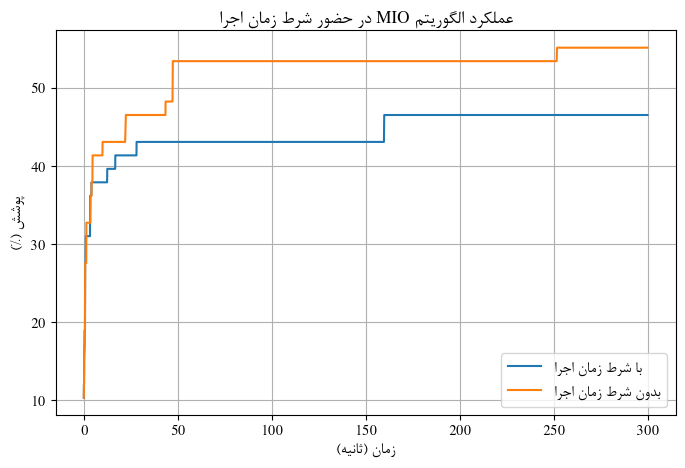

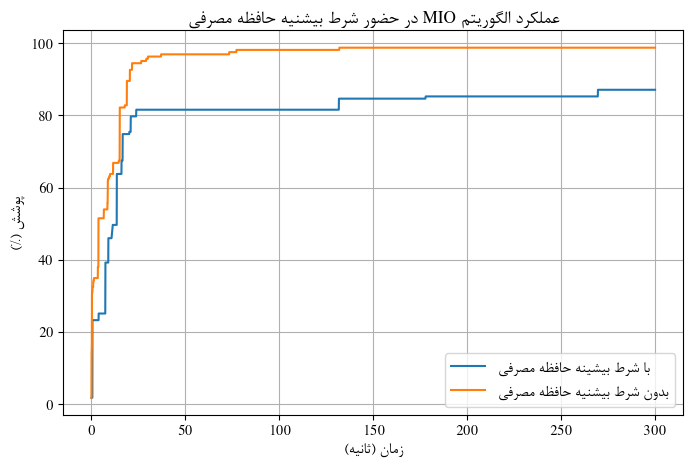

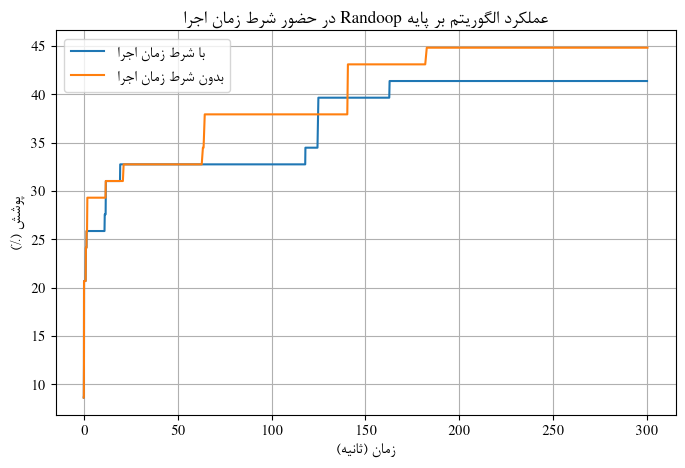

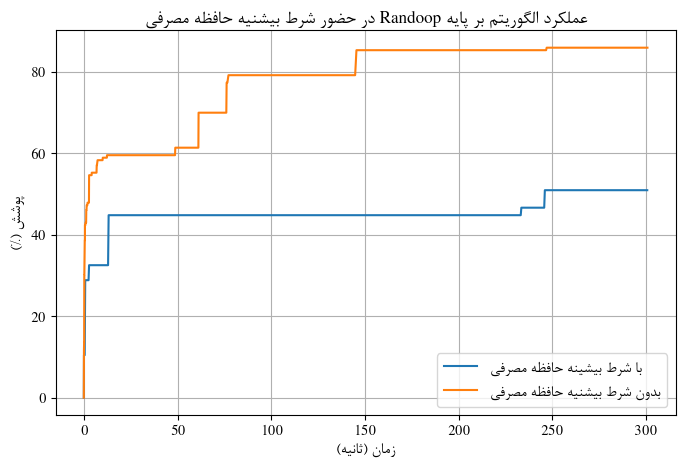

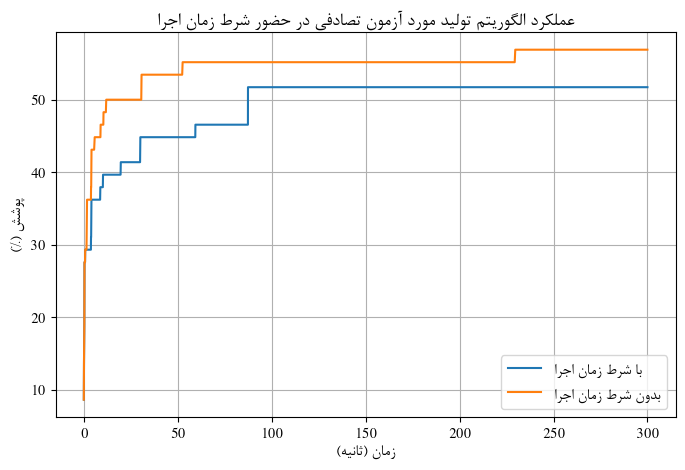

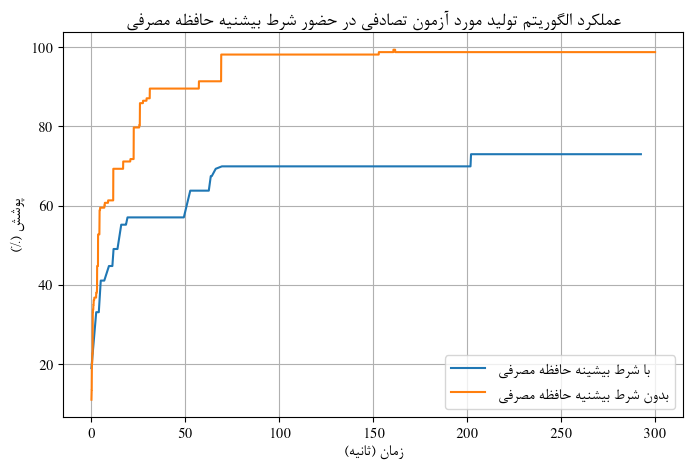

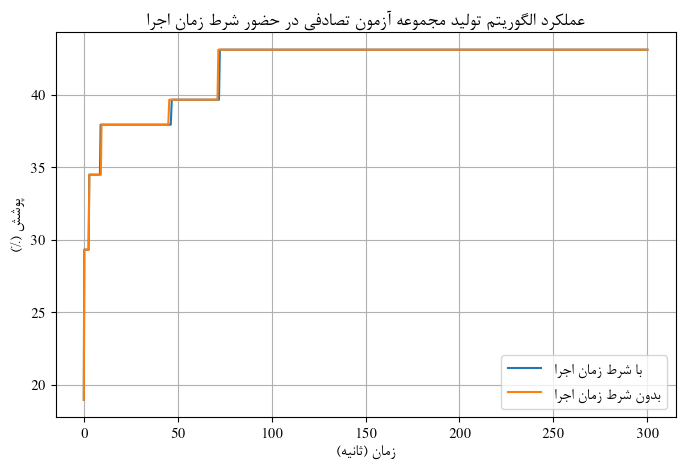

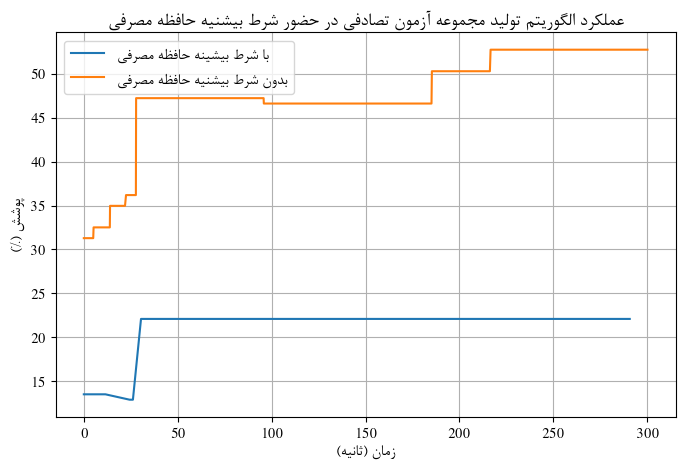

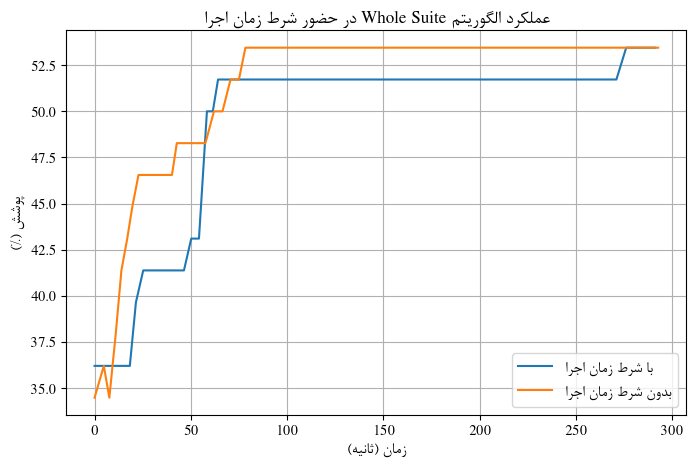

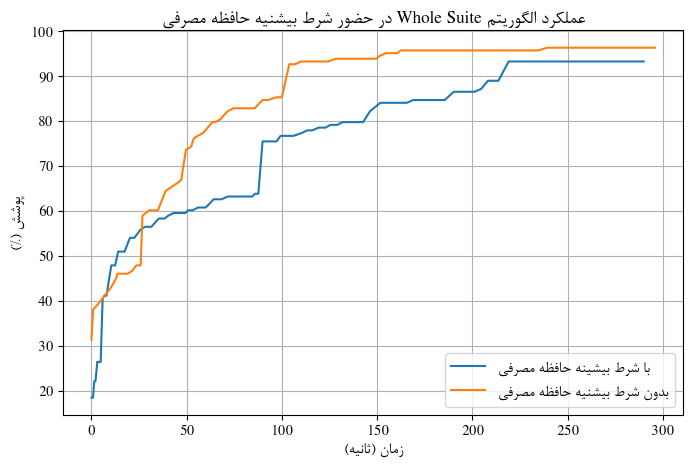

In [29]:
plt.rcParams["font.family"] = ["Nazli"] # Titr or Nazli
plt.rcParams["font.size"] = 12
plt.rcParams["axes.unicode_minus"] = False  # Fix negative sign issues

def persian_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

FA_ALGORITHMS = {
    "DYNAMOSA": "DynaMOSA",
    "MOSA": "MOSA",
    "MIO": "MIO",
    "RANDOM": "بر پایه Randoop",
    "RANDOM_TEST_CASE_SEARCH": "تولید مورد آزمون تصادفی",
    "RANDOM_TEST_SUITE_SEARCH": "تولید مجموعه آزمون تصادفی",
    "WHOLE_SUITE": "Whole Suite",
}

for algo in ALGORITHMS:
    # Create plot
    # x_labels = [0, 1, 2, 3]
    # x_labels_persian = [en_to_fa(str(x)) for x in x_labels]  # Convert to Persian digits
    # plt.xticks(x_labels, x_labels_persian)

    plt.figure(figsize=(8, 5))
    plt.title(persian_text(f"عملکرد الگوریتم {FA_ALGORITHMS[algo]} در حضور شرط زمان اجرا"))
    plt.plot(info[algo]["time"]["t"], info[algo]["time"]["cov"], label=persian_text("با شرط زمان اجرا"))
    plt.plot(info[algo]["no_time"]["t"], info[algo]["no_time"]["cov"], label=persian_text("بدون شرط زمان اجرا"))
    plt.xlabel(persian_text("زمان (ثانیه)"))
    plt.ylabel(persian_text("پوشش (٪)"))
    plt.grid(True)
    plt.legend()
    plt.savefig(f"../results/plots/{algo}_time.jpeg")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.title(persian_text(f"عملکرد الگوریتم {FA_ALGORITHMS[algo]} در حضور شرط بیشنیه حافظه مصرفی"))
    plt.plot(info[algo]["mem"]["t"], info[algo]["mem"]["cov"], label=persian_text("با شرط بیشینه حافظه مصرفی"))
    plt.plot(info[algo]["no_mem"]["t"], info[algo]["no_mem"]["cov"], label=persian_text("بدون شرط بیشنیه حافظه مصرفی"))
    plt.xlabel(persian_text("زمان (ثانیه)"))
    plt.ylabel(persian_text("پوشش (٪)"))
    plt.grid(True)    
    plt.legend()
    plt.savefig(f"../results/plots/{algo}_memory.jpeg")
    plt.show()